# Dealing with Categorical Variables - Lab

## Introduction

In this lab, you'll explore the Ames Housing dataset and identify numeric and categorical variables. Then you'll transform some categorical data and use it in a multiple regression model.

## Objectives

You will be able to:

* Determine whether variables are categorical or numeric
* Use one-hot encoding to create dummy variables

## Step 1: Load the Ames Housing Dataset

Import `pandas`, and use it to load the file `ames.csv` into a dataframe called `ames`. If you pass in the argument `index_col=0` this will set the "Id" feature as the index.

In [1]:
# Your code here - load the dataset
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error,r2_score,mean_absolute_error
import matplotlib.pyplot as plt
%matplotlib inline

df = pd.read_csv('ames.csv',index_col=0)

Visually inspect `ames` (it's ok if you can't see all of the columns).

In [2]:
# Your code here
df.head(5)

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [3]:
df.info

<bound method DataFrame.info of       MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
Id                                                                      
1             60       RL         65.0     8450   Pave   NaN      Reg   
2             20       RL         80.0     9600   Pave   NaN      Reg   
3             60       RL         68.0    11250   Pave   NaN      IR1   
4             70       RL         60.0     9550   Pave   NaN      IR1   
5             60       RL         84.0    14260   Pave   NaN      IR1   
...          ...      ...          ...      ...    ...   ...      ...   
1456          60       RL         62.0     7917   Pave   NaN      Reg   
1457          20       RL         85.0    13175   Pave   NaN      Reg   
1458          70       RL         66.0     9042   Pave   NaN      Reg   
1459          20       RL         68.0     9717   Pave   NaN      Reg   
1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour U

Go ahead and drop all **columns** with missing data, to simplify the problem. Remember that you can use the `dropna` method ([documentation here](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html)).

In [4]:
# Your code here - drop columns with missing data
df = df.dropna(axis=1)

In [5]:
df.info

<bound method DataFrame.info of       MSSubClass MSZoning  LotArea Street LotShape LandContour Utilities  \
Id                                                                         
1             60       RL     8450   Pave      Reg         Lvl    AllPub   
2             20       RL     9600   Pave      Reg         Lvl    AllPub   
3             60       RL    11250   Pave      IR1         Lvl    AllPub   
4             70       RL     9550   Pave      IR1         Lvl    AllPub   
5             60       RL    14260   Pave      IR1         Lvl    AllPub   
...          ...      ...      ...    ...      ...         ...       ...   
1456          60       RL     7917   Pave      Reg         Lvl    AllPub   
1457          20       RL    13175   Pave      Reg         Lvl    AllPub   
1458          70       RL     9042   Pave      Reg         Lvl    AllPub   
1459          20       RL     9717   Pave      Reg         Lvl    AllPub   
1460          20       RL     9937   Pave      Reg      

## Step 2: Identify Numeric and Categorical Variables

The file `data_description.txt`, located in this repository, has a full description of all variables.

Using this file as well as `pandas` techniques, identify the following predictors:

1. A **continuous numeric** predictor
2. A **discrete numeric** predictor
3. A **string categorical** predictor
4. A **discrete categorical** predictor

(Note that `SalePrice` is the target variable and should not be selected as a predictor.)

For each of these predictors, visualize the relationship between the predictor and `SalePrice` using an appropriate plot.

Finding these will take some digging -- don't be discouraged if they're not immediately obvious. The Ames Housing dataset is a lot more complex than the Auto MPG dataset. There is also no single right answer here.

### Continuous Numeric Predictor

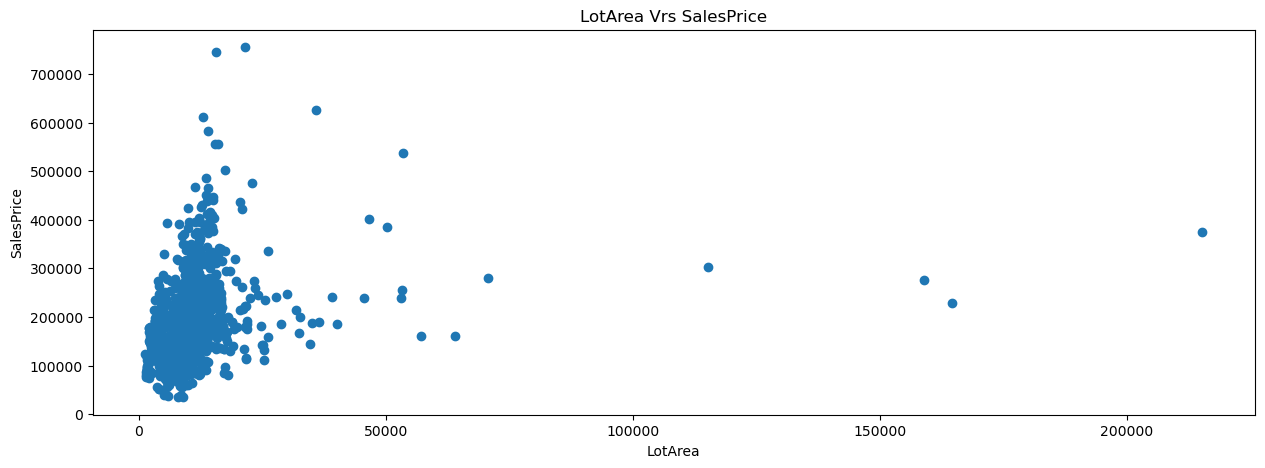

In [6]:
# Your code here - continuous numeric predictor
fig = plt.figure(figsize =(15,5))
plt.scatter(df['LotArea'],df['SalePrice'])
plt.title('LotArea Vrs SalesPrice')
plt.xlabel('LotArea')
plt.ylabel('SalesPrice')
plt.show()

### Discrete Numeric Predictor

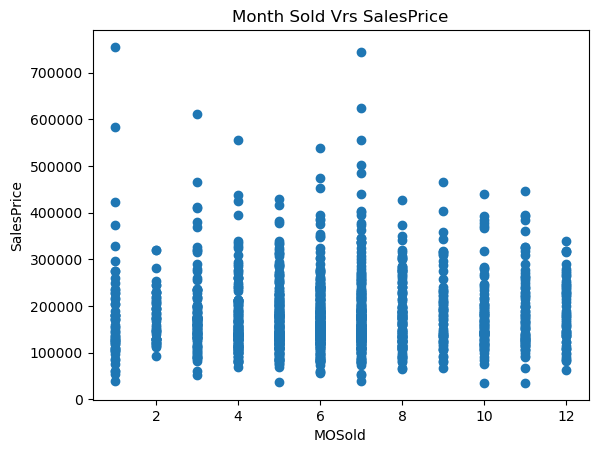

In [7]:
# Your code here - discrete numeric predictor
plt.scatter(df['MoSold'],df['SalePrice'])
plt.title('Month Sold Vrs SalesPrice')
plt.xlabel('MOSold')
plt.ylabel('SalesPrice')
plt.show()

### String Categorical Predictor

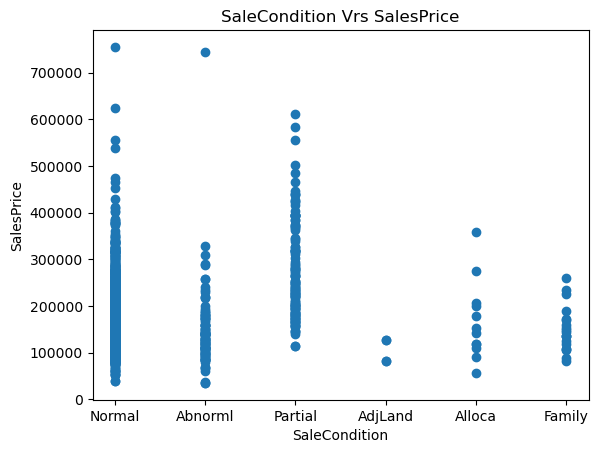

In [8]:
# Your code here - string categorical predictor
plt.scatter(df['SaleCondition'],df['SalePrice'])
plt.title('SaleCondition Vrs SalesPrice')
plt.xlabel('SaleCondition')
plt.ylabel('SalesPrice')
plt.show()

### Discrete Categorical Predictor

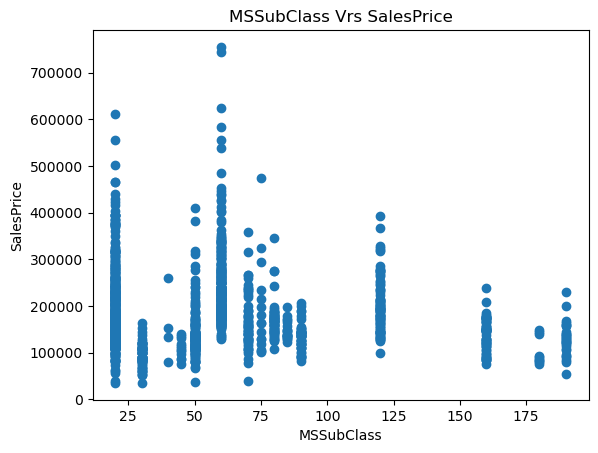

In [9]:
# Your code here - discrete categorical predictor
plt.scatter(df['MSSubClass'],df['SalePrice'])
plt.title('MSSubClass Vrs SalesPrice')
plt.xlabel('MSSubClass')
plt.ylabel('SalesPrice')
plt.show()

## Step 3: Build a Multiple Regression Model with Your Chosen Predictors

Choose the best-looking 3 out of 4 predictors to include in your model.

Make sure that you one-hot encode your categorical predictor(s) (regardless of whether the current data type is a string or number) first.

In [10]:
df.head()

,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
Id,,,,,,,,,,,,,,,,,,,,,
1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,2,2008,WD,Normal,208500
2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,0,0,0,0,0,5,2007,WD,Normal,181500
3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,0,0,0,0,0,9,2008,WD,Normal,223500
4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [11]:
# Your code here - prepare X and y, including one-hot encoding
features = ['LotArea','MoSold','SaleCondition']
target = ['SalePrice']

x = df[features]
y = df[target]


In [12]:
df['SaleCondition'].unique()

array(['Normal', 'Abnorml', 'Partial', 'AdjLand', 'Alloca', 'Family'],
      dtype=object)

In [13]:
# Your answer here - which category or categories were dropped?
x_encode = pd.get_dummies(x, drop_first = True).astype(int)
x_encode
#The Adnormal was dropped.

,LotArea,MoSold,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
Id,,,,,,,
1,8450,2,0,0,0,1,0
2,9600,5,0,0,0,1,0
3,11250,9,0,0,0,1,0
4,9550,2,0,0,0,0,0
5,14260,12,0,0,0,1,0
...,...,...,...,...,...,...,...
1456,7917,8,0,0,0,1,0
1457,13175,2,0,0,0,1,0
1458,9042,5,0,0,0,1,0


In [14]:
# Your code here - build a regression model and display results
x_encode = sm.add_constant(x_encode)
model = sm.OLS(y, x_encode).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.200
Model:                            OLS   Adj. R-squared:                  0.196
Method:                 Least Squares   F-statistic:                     51.74
Date:                Wed, 09 Apr 2025   Prob (F-statistic):           4.80e-66
Time:                        21:39:58   Log-Likelihood:                -18381.
No. Observations:                1460   AIC:                         3.678e+04
Df Residuals:                    1452   BIC:                         3.682e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                  1.244e+

## Step 4: Create Partial Regression Plots for Features

For each feature of the regression above (including the dummy features), plot the partial regression.

C:\Users\MichelleChekwooti\anaconda3\Lib\site-packages\statsmodels\graphics\regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)
C:\Users\MichelleChekwooti\anaconda3\Lib\site-packages\statsmodels\graphics\regressionplots.py:430: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  fig = abline_plot(0, fitted_line.params[0], color='k', ax=ax)


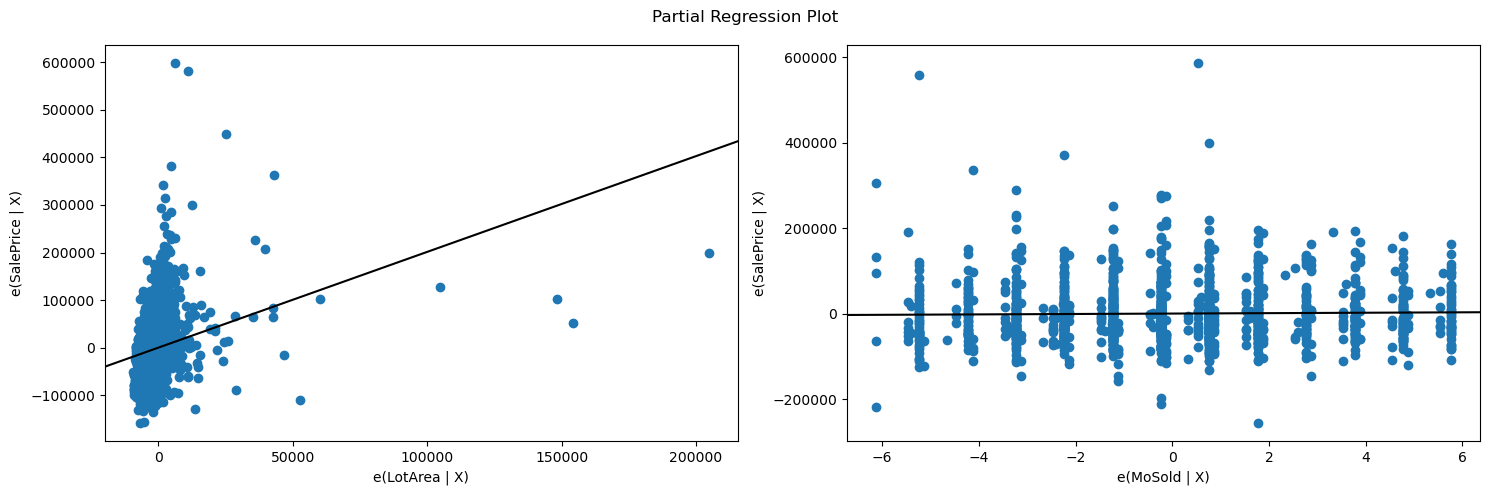

In [15]:
# Your code here - create partial regression plots
fig = plt.figure(figsize=(15,5))
sm.graphics.plot_partregress_grid(model, exog_idx= ['LotArea','MoSold'], fig=fig)
plt.tight_layout()
plt.show()

## Step 5: Calculate an Error-Based Metric

In addition to the adjusted R-Squared that we can see in the model summary, calculate either MAE or RMSE for this model.

In [18]:
# Your code here - calculate an error-based metric
mae = mean_absolute_error(y, model)
print("MAE:",mae)

TypeError: Expected sequence or array-like, got <class 'statsmodels.regression.linear_model.RegressionResultsWrapper'>

## Step 6: Summarize Findings

Between the model results, partial regression plots, and error-based metric, what does this model tell you? What would your next steps be to improve the model?

In [36]:
# Your answer here
'''

'''

## Level Up (Optional)

Try transforming X using scikit-learn _and_ fitting a scikit-learn linear regression as well. If there are any differences in the result, investigate them.

In [38]:
# Your code here

## Summary

In this lab, you practiced your knowledge of categorical variables on the Ames Housing dataset! Specifically, you practiced distinguishing numeric and categorical data. You then created dummy variables using one hot encoding in order to build a multiple regression model.